## Learning to rank with LambdaMART

In this notebook we apply the LambdaMART, a pairwise learning to rank method, to a text search data set. We use the XGBoost implementation of LambdaMART. 

In [1]:
import numpy as np
import pickle
import xgboost as xgb
import graphviz
import matplotlib
import math

## Data

The data we use is the Microsoft MSLR-10K dataset, and can be downloaded [here](https://www.microsoft.com/en-us/research/project/mslr/).

The data is a LETOR data set (LEarning TO Rank), of the form: "reference lable (ie ranking given by human), query id, query-url pairs (length 136 feature vec)". It is commonly used for learning to rank benchmarking. 

The data has been pre-processed by a bash script which stores grouping information from the query ids in a .txt.group file, and removes the query id from the raw datasets.  

In [8]:
import os
os.listdir('MSLR-WEB10K/Fold1/')

['process_data.sh', 'train.txt', 'vali.txt', 'test.txt']

In [11]:
from sklearn.datasets import load_svmlight_file
import numpy as np

# Load directly from train.txt (qid included)
X_train, y_train, qid_train = load_svmlight_file('MSLR-WEB10K/Fold1/train.txt', query_id=True)
X_test, y_test, qid_test = load_svmlight_file('MSLR-WEB10K/Fold1/test.txt', query_id=True)

# Build groups from qids
def qids_to_groups(qids):
    _, counts = np.unique(qids, return_counts=True)
    return counts.tolist()

train_groups = qids_to_groups(qid_train)
test_groups = qids_to_groups(qid_test)

# Build DMatrix
training_data = xgb.DMatrix(X_train, label=y_train)
training_data.set_group(train_groups)

testing_data = xgb.DMatrix(X_test, label=y_test)
testing_data.set_group(test_groups)

## Building a Model

We now set the model parameters:

'max_depth' = number of layers in the tree
'eta' = step shrinkage size, used to prevent overfitting
'silent' = if 1, doesn't print updates. 
'objective' = which method is used/which objective function is minimised. 'rank:pairwise' implements LambdaMART.
'num_round' = number of boosting rounds. 

In [12]:
param = {'max_depth':6, 'eta':0.3, 'silent':0, 'objective':'rank:pairwise', 'num_round':10}

In [13]:
model = xgb.train(param, training_data)

/Users/test/project/XGBoost-lambdaMART/venv/lib/python3.13/site-packages/xgboost/training.py:200: UserWarning: [10:32:11] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "num_round", "silent" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Visualising the model

The model takes the form of a decision tree, where splits at nodes are conditional on the inputted features in the feature vector for each query.  

In [14]:
%matplotlib inline

ExecutableNotFound: failed to execute PosixPath('dot'), make sure the Graphviz executables are on your systems' PATH

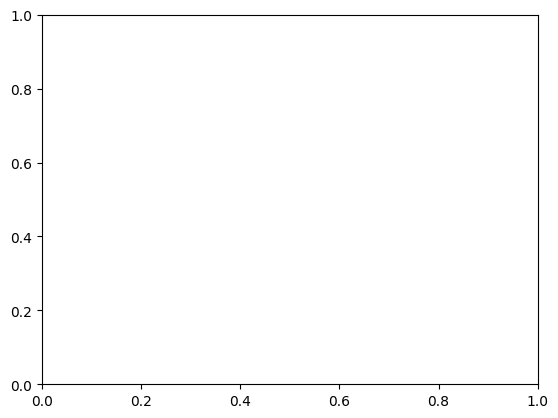

In [17]:
xgb.plot_tree(model, tree_idx=0)
fig = matplotlib.pyplot.gcf()
fig.set_size_inches(150, 100)

It is possible to look a the importance of each of the 136 features within the model. In the feature plot below we see that the most 'important' feature in determining the output of the model for a given input is feature 134. 

In this data set we used, feature 134 corresponds to the click count of a query-url pair at a search engine in a period. 

Feature 108 and 129 are the BM25 of the page's title and the number of outlinks on the page, respectively. BM25 relates to the frequency of terms in the query appearing in a block of text. 

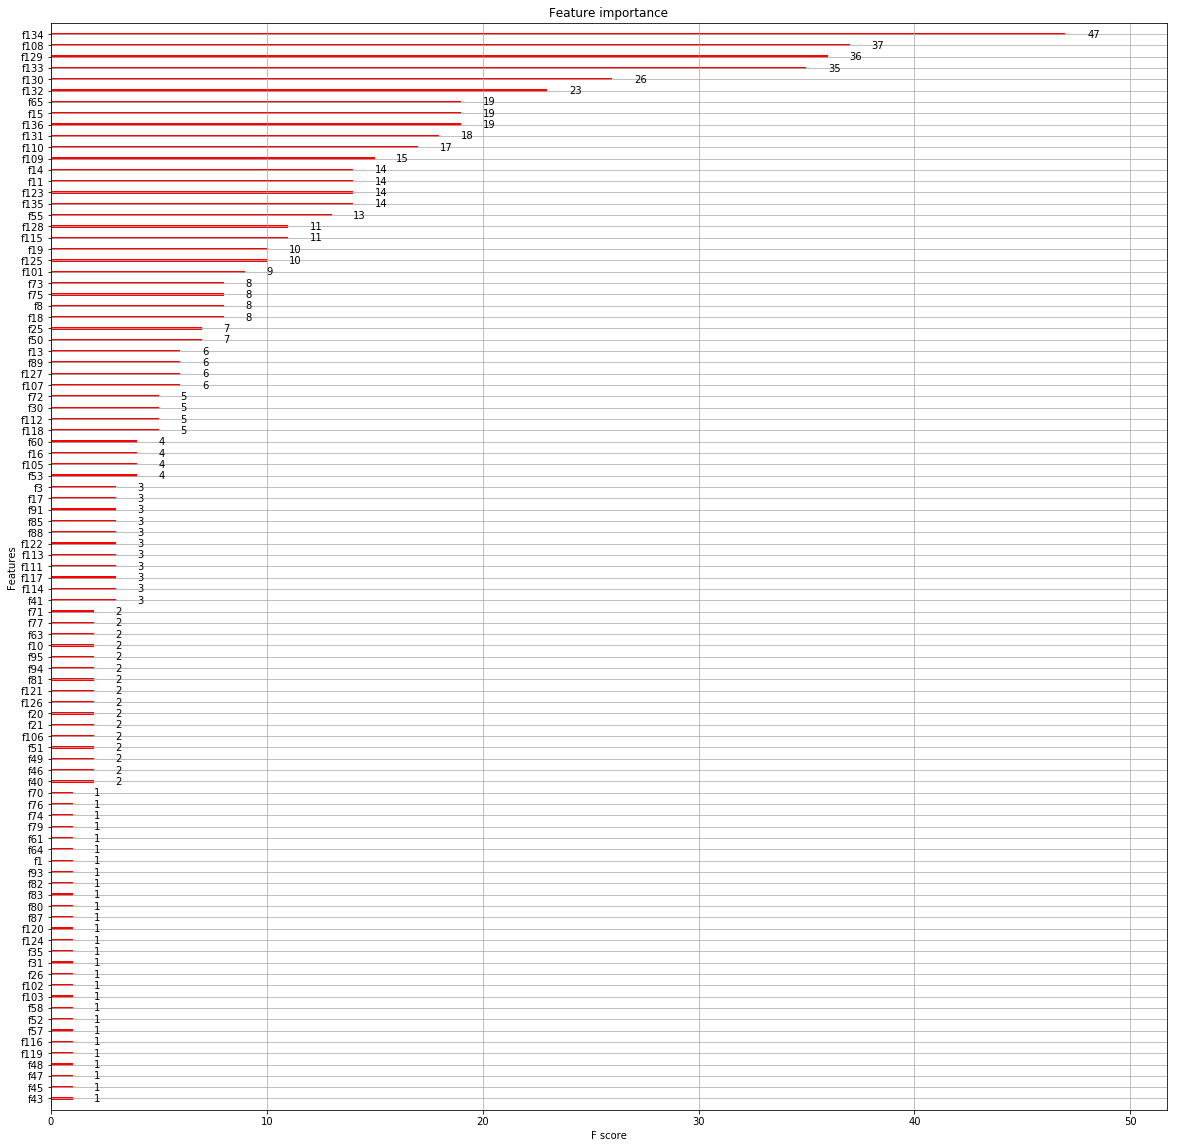

In [7]:
ax = xgb.plot_importance(model, color='red')
fig = ax.figure
fig.set_size_inches(20, 20)

## Making predictions

'preds' contains predicted relelvance values for all of the queries in the testing data set. We want to compute the normalised discounted cumulative gain, or ndgc, of the results, in order to quantify the goodness of the model. This will allow us to compare models and tuning parameters. 

Predictions are made by passing a feature vector from the testing data set through the decision tree, ending at a leaf which gives a numerical value. The numerical value represents the relavance of that document for that query. 

In [8]:
preds = model.predict(testing_data)

In [9]:
preds

array([0.5705693 , 0.13573161, 0.23310575, ..., 0.92486215, 0.21065465,
       0.03313828], dtype=float32)

### Normal Distributed Cumulative Gain 
ndcg is a metric commonly used to rate the output of learning to rank models.
ndcg is a measure of the relative goodness of the output of the ranking algorithm, and takes value between 0 and 1, with a 1 denoting that the algorithm has optimally ordered the pages for a query, and a 0 denoting that the pages have been reverse ordered. 

In [10]:
""" this returns 0 if all of the ordered data is undesirable"""
def ndcg_p(ordered_data, p):
    """normalised discounted cumulative gain"""
    if sum(ordered_data)==0:
        return 0
    else:
        indexloop = range(0, p)
        DCG_p = 0
        for index in indexloop:
            current_ratio=(2**(ordered_data[index])-1)*(math.log((float(index)+2), 2)**(-1))
            DCG_p = DCG_p + current_ratio
        ordered_data.sort(reverse=True)  
        K = len(ordered_data)
        indexloop = range(0, K)
        iDCG_p = 0
        for index in indexloop:
            current_ratio=(2**(ordered_data[index])-1)*((math.log((index+2), 2))**(-1))
            iDCG_p = iDCG_p + current_ratio
        return(DCG_p/iDCG_p)

In [11]:
f = open('../LearningToRank/MSLR-WEB10K/Fold1/test_dat.txt.group', 'r')
x = f.readlines()
groups =[]
for line in x:
    groups.append(int(line))
f.close()

In [12]:
testing_labels = testing_data.get_label()

In [13]:
## compute ndgc for each query.
nquerys=range(0,len(groups))
lower=0
upper=0
ndcgs=[]
for i in nquerys:
        many=groups[i]
        upper = upper+many
        predicted = preds[lower:upper]
        labled = testing_labels[lower:upper]
        ordered = [x for _,x in sorted(zip(predicted,labled), reverse=True)]
        result = ndcg_p(ordered, many)
        ndcgs.append(result)
        lower=upper


In [14]:
ndcgs

[0.7920157908597824,
 1.0,
 0.6696320897097504,
 0.4321311307627513,
 0.7292906799182761,
 0.6709282865041498,
 0.691977589084363,
 0.7248029847160538,
 0.6512841556481817,
 0.6584181249793338,
 0.7931044654204512,
 0.7140440037630282,
 0.5299368731205177,
 0.7289583293534868,
 0.5178860488063297,
 0.6043998367862156,
 0.6168015795138558,
 0.7214322338470472,
 0.6664498435766764,
 0.8321509327629493,
 0.748022769969937,
 0.5659253563929745,
 0.4679105405562421,
 0.6204817213175754,
 0.6542312112248714,
 0.8605408459568462,
 0.5940894742008946,
 0.8929481249055113,
 0.7986348707604983,
 0.7352827419758698,
 0.6876827756396034,
 0.57081082540348,
 0.840700010240868,
 0.6278070773819843,
 0.7461264011771848,
 0.7496393488919593,
 0.755671783029136,
 0.735555095566083,
 0.712369081330788,
 0.6215891997769276,
 0.7774298203824601,
 0.6738304325753472,
 0.6569343651317164,
 0.7811538776127928,
 0.6877652955089816,
 0.7863754032241544,
 0.7645244536900541,
 0.8616372683133378,
 0.580663213768

For each query we see a number between 0 and 1 denoting how well the pages for that query were ordered. 